# id_00 ↔ id_02 혼동 가설 진단

분류 기반 다중 seed 실험에서 seed 4일 때 id_00과 id_02 AUC가 함께 낮아졌다.  
두 기계의 정상 소리가 비슷해 서로 혼동된다는 가설을 혼동행렬과 평균 softmax 확률로 검증한다.

- 급락 조건: seed 4
- 대조 조건: seed 1
- 혼동행렬: 행=실제 기계, 열=모델이 예측한 기계


In [1]:
## [0] 준비
# 노트북은 notebooks 폴더에서 실행되므로 프로젝트 루트를 import 경로에 추가한다.
import sys
sys.path.insert(0, '..')

# torch와 다른 라이브러리의 OpenMP 충돌을 막는다.
# 반드시 torch를 import하기 전에 환경 변수를 설정해야 한다.
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
from src import data, train, evaluate
from src.model import IDClassifier

# 확률을 비교하기 쉽도록 소수점 넷째 자리까지 표시한다.
np.set_printoptions(precision=4, suppress=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
print('학습 장치 :', DEVICE)


학습 장치 : cuda


In [2]:
## [1] 한 seed를 학습하고 정상 테스트의 혼동행렬·평균 확률 계산
## -> 함수 기능 : 지정한 seed의 ID 분류기를 학습하고 정상 혼동을 진단
## -> 매개 변수 : seed - 데이터 분할·모델 초기값을 정하는 정수
## -> 함수 결과 : confusionNP, mean_proba, auc_results
def diagnose_seed(seed):
    # 모델 초기값과 DataLoader 셔플 순서를 현재 seed로 고정한다.
    torch.manual_seed(seed)

    # 같은 seed로 정상 데이터를 80:20 분할하고 전역 MIN/MAX로 정규화한다.
    X_trainNP, y_trainNP, tests = data.load_for_classification(seed=seed)

    # seed마다 새 모델을 생성하고 기존 하이퍼파라미터로 정상 소리만 학습한다.
    model = IDClassifier().to(DEVICE)
    model = train.train_classifier(model, X_trainNP, y_trainNP, DEVICE)

    # 행은 실제 기계, 열은 모델이 예측한 기계인 4×4 행렬을 만든다.
    confusionNP = np.zeros((4, 4), dtype=int)
    mean_proba = {}
    auc_results = {}

    for machine, test_data in tests.items():
        machine_idx, test_normalNP, test_abnormalNP = test_data

        # 정상 테스트 샘플마다 4개 기계일 softmax 확률을 구한다.
        probaNP = evaluate.predict_proba(model, test_normalNP, DEVICE)
        predictedNP = np.argmax(probaNP, axis=1)

        # 실제 기계 행에서 모델이 고른 기계 열의 개수를 1씩 증가시킨다.
        for predicted_idx in predictedNP:
            confusionNP[machine_idx, predicted_idx] += 1

        # 샘플축 평균을 내면 해당 기계 정상의 평균 확률 4개가 된다.
        mean_proba[machine] = probaNP.mean(axis=0)

        # 이전 다중 seed AUC가 같은 조건에서 재현되는지도 함께 확인한다.
        auc = evaluate.classifier_auc(
            model, machine_idx, test_normalNP, test_abnormalNP, DEVICE)
        auc_results[machine] = auc

    return confusionNP, mean_proba, auc_results


In [3]:
## [2] 급락 seed 4와 안정 seed 1을 같은 방식으로 진단
DIAGNOSIS_SEEDS = [4, 1]
diagnosis = {}

for seed in DIAGNOSIS_SEEDS:
    confusionNP, mean_proba, auc_results = diagnose_seed(seed)
    diagnosis[seed] = (confusionNP, mean_proba, auc_results)

    print(f'\n===== seed {seed} =====')
    print('혼동행렬 (행=실제, 열=예측)')
    print('열 순서 :', MACHINES)
    print(confusionNP)

    print('정상 테스트 평균 softmax')
    for machine in MACHINES:
        print(machine, mean_proba[machine])

    print('AUC 재현 확인')
    for machine in MACHINES:
        print(f'{machine}: {auc_results[machine]:.4f}')



===== seed 4 =====
혼동행렬 (행=실제, 열=예측)
열 순서 : ['id_00', 'id_02', 'id_04', 'id_06']
[[202  10   1   1]
 [  6 205   2   1]
 [  0   0 106   1]
 [  0   1   0 106]]
정상 테스트 평균 softmax
id_00 [0.9317 0.0585 0.0025 0.0073]
id_02 [0.052  0.936  0.0078 0.0043]
id_04 [0.0019 0.0009 0.9882 0.009 ]
id_06 [0.0016 0.0114 0.0012 0.9858]
AUC 재현 확인
id_00: 0.9203
id_02: 0.8963
id_04: 0.9849
id_06: 0.8003

===== seed 1 =====
혼동행렬 (행=실제, 열=예측)
열 순서 : ['id_00', 'id_02', 'id_04', 'id_06']
[[204   8   0   2]
 [ 30 182   2   0]
 [  0   0 107   0]
 [  4   0   0 103]]
정상 테스트 평균 softmax
id_00 [0.9325 0.0527 0.0014 0.0133]
id_02 [0.1843 0.8057 0.0084 0.0016]
id_04 [0.     0.0005 0.999  0.0005]
id_06 [0.0323 0.0021 0.0025 0.9631]
AUC 재현 확인
id_00: 0.9912
id_02: 0.9692
id_04: 0.9199
id_06: 0.7403


In [4]:
## [3] id_00 ↔ id_02 핵심 혼동 수치 나란히 비교
print('seed | id_00→id_02 | id_02→id_00 | id_00의 평균 p(id_00), p(id_02)')
print('-' * 82)

for seed in DIAGNOSIS_SEEDS:
    confusionNP, mean_proba, auc_results = diagnosis[seed]
    count_00_to_02 = confusionNP[0, 1]
    count_02_to_00 = confusionNP[1, 0]
    mean_00NP = mean_proba['id_00']
    print(
        f'{seed} | {count_00_to_02} | {count_02_to_00} | '
        f'{mean_00NP[0]:.4f}, {mean_00NP[1]:.4f}')


seed | id_00→id_02 | id_02→id_00 | id_00의 평균 p(id_00), p(id_02)
----------------------------------------------------------------------------------
4 | 10 | 6 | 0.9317, 0.0585
1 | 8 | 30 | 0.9325, 0.0527


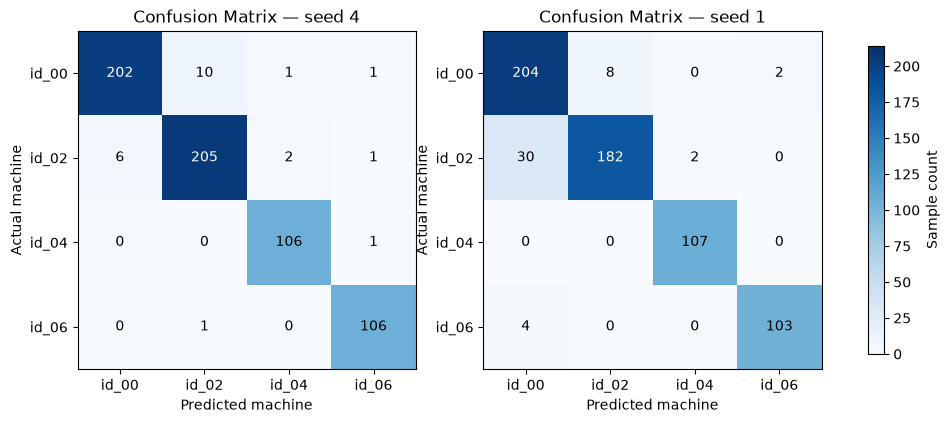

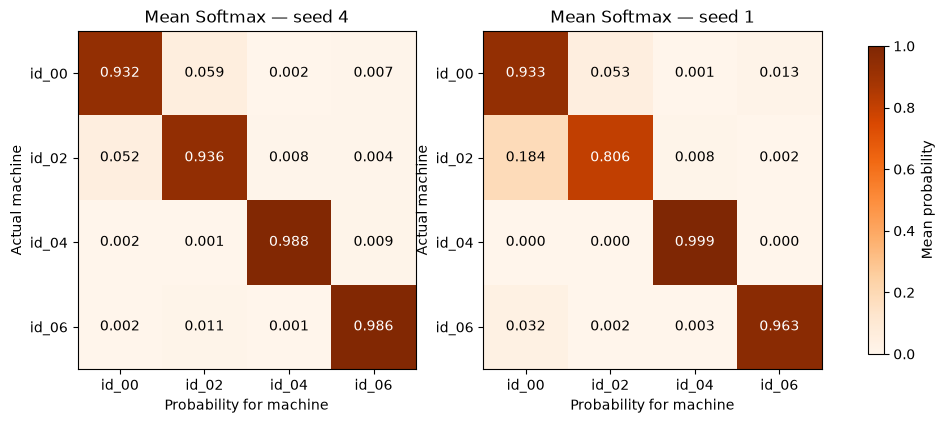

In [5]:
## [4] seed 4와 seed 1의 혼동행렬·평균 softmax 시각화
# 숫자 표만으로 놓치기 쉬운 혼동 방향과 확률 집중도를 heatmap으로 비교한다.
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 첫 번째 그림: 정상 테스트 혼동행렬의 실제 개수를 표시한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for plot_idx in range(len(DIAGNOSIS_SEEDS)):
    seed = DIAGNOSIS_SEEDS[plot_idx]
    confusionNP, mean_proba, auc_results = diagnosis[seed]
    image = axes[plot_idx].imshow(confusionNP, cmap='Blues', vmin=0, vmax=214)
    axes[plot_idx].set_title(f'혼동행렬 — 시드 {seed}')
    axes[plot_idx].set_xlabel('예측 기계')
    axes[plot_idx].set_ylabel('실제 기계')
    axes[plot_idx].set_xticks(range(4), MACHINES)
    axes[plot_idx].set_yticks(range(4), MACHINES)

    # 각 칸에 실제 샘플 수를 적어 색과 숫자를 함께 확인한다.
    for row in range(4):
        for col in range(4):
            value = confusionNP[row, col]
            text_color = 'white' if value > 107 else 'black'
            axes[plot_idx].text(col, row, value, ha='center', va='center', color=text_color)

fig.colorbar(image, ax=axes, shrink=0.8, label='샘플 수')
plt.show()

# 두 번째 그림: 실제 기계별 평균 softmax 4개를 4×4 heatmap으로 표시한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for plot_idx in range(len(DIAGNOSIS_SEEDS)):
    seed = DIAGNOSIS_SEEDS[plot_idx]
    confusionNP, mean_proba, auc_results = diagnosis[seed]
    mean_probaNP = np.zeros((4, 4))

    for machine_idx in range(len(MACHINES)):
        machine = MACHINES[machine_idx]
        mean_probaNP[machine_idx] = mean_proba[machine]

    image = axes[plot_idx].imshow(mean_probaNP, cmap='Oranges', vmin=0, vmax=1)
    axes[plot_idx].set_title(f'평균 softmax — 시드 {seed}')
    axes[plot_idx].set_xlabel('기계별 예측 확률')
    axes[plot_idx].set_ylabel('실제 기계')
    axes[plot_idx].set_xticks(range(4), MACHINES)
    axes[plot_idx].set_yticks(range(4), MACHINES)

    # 각 칸에 평균 확률을 표시해 작은 혼동도 정확히 읽을 수 있게 한다.
    for row in range(4):
        for col in range(4):
            value = mean_probaNP[row, col]
            text_color = 'white' if value > 0.5 else 'black'
            axes[plot_idx].text(
                col, row, f'{value:.3f}', ha='center', va='center', color=text_color)

fig.colorbar(image, ax=axes, shrink=0.8, label='평균 확률')
plt.show()


## 이상측 점수 진단

정상 ID 혼동이 AUC 급락의 직접 원인이 아니었으므로, 이번에는 이상 소리가 해당 기계의 정상처럼 높은 확률을 받는지 확인한다.  정상과 이상의 `p(해당 기계)` 평균·격차와 이상점수 분포를 seed 4와 seed 1에서 비교한다.


In [6]:
## [5] 정상·이상 p(해당 기계) 평균과 격차 계산
# 급락 조건 seed 4와 대조 조건 seed 1을 같은 방식으로 다시 학습한다.
ABNORMAL_SEEDS = [4, 1]
score_diagnosis = {}

for seed in ABNORMAL_SEEDS:
    # 모델 초기값과 DataLoader 셔플 순서를 현재 seed로 고정한다.
    torch.manual_seed(seed)

    # 같은 seed로 데이터를 분할하고, 새 ID 분류기를 정상 데이터만으로 학습한다.
    X_trainNP, y_trainNP, tests = data.load_for_classification(seed=seed)
    score_model = IDClassifier().to(DEVICE)
    score_model = train.train_classifier(
        score_model, X_trainNP, y_trainNP, DEVICE)

    seed_scores = {}
    print(f'\n===== seed {seed}: 정상·이상 확률 진단 =====')
    print('기계 | 정상 평균 p | 이상 평균 p | 격차(정상-이상) | AUC')
    print('-' * 72)

    for machine, test_data in tests.items():
        machine_idx, test_normalNP, test_abnormalNP = test_data

        # 정상과 이상 샘플마다 4개 기계 softmax 확률을 계산한다.
        normal_probaNP = evaluate.predict_proba(
            score_model, test_normalNP, DEVICE)
        abnormal_probaNP = evaluate.predict_proba(
            score_model, test_abnormalNP, DEVICE)

        # 4개 확률 중 실제 해당 기계 index의 확률만 뽑는다.
        normal_targetNP = normal_probaNP[:, machine_idx]
        abnormal_targetNP = abnormal_probaNP[:, machine_idx]

        NORMAL_MEAN = normal_targetNP.mean()
        ABNORMAL_MEAN = abnormal_targetNP.mean()
        PROBABILITY_GAP = NORMAL_MEAN - ABNORMAL_MEAN

        # 히스토그램은 이상점수 1-p(해당 기계)를 사용한다.
        normal_scoreNP = 1 - normal_targetNP
        abnormal_scoreNP = 1 - abnormal_targetNP
        auc = evaluate.classifier_auc(
            score_model, machine_idx, test_normalNP, test_abnormalNP, DEVICE)

        seed_scores[machine] = {
            'normal_mean': NORMAL_MEAN,
            'abnormal_mean': ABNORMAL_MEAN,
            'gap': PROBABILITY_GAP,
            'normal_scoreNP': normal_scoreNP,
            'abnormal_scoreNP': abnormal_scoreNP,
            'auc': auc,
        }

        print(
            f'{machine} | {NORMAL_MEAN:.4f} | {ABNORMAL_MEAN:.4f} | '
            f'{PROBABILITY_GAP:.4f} | {auc:.4f}')

    score_diagnosis[seed] = seed_scores



===== seed 4: 정상·이상 확률 진단 =====
기계 | 정상 평균 p | 이상 평균 p | 격차(정상-이상) | AUC
------------------------------------------------------------------------
id_00 | 0.9384 | 0.4715 | 0.4668 | 0.8557
id_02 | 0.9580 | 0.7707 | 0.1872 | 0.7401
id_04 | 0.9934 | 0.1002 | 0.8932 | 0.9994
id_06 | 0.9691 | 0.8720 | 0.0971 | 0.7921

===== seed 1: 정상·이상 확률 진단 =====
기계 | 정상 평균 p | 이상 평균 p | 격차(정상-이상) | AUC
------------------------------------------------------------------------
id_00 | 0.9198 | 0.0331 | 0.8867 | 0.9927
id_02 | 0.7796 | 0.0481 | 0.7315 | 0.9664
id_04 | 0.9899 | 0.7462 | 0.2437 | 0.9588
id_06 | 0.9557 | 0.9175 | 0.0382 | 0.6995


In [ ]:
## [6] 기계별 정상·이상 이상점수 히스토그램
# 행은 seed 4/1, 열은 네 기계로 배치해 분포 겹침 정도를 한눈에 비교한다.
import matplotlib.pyplot as plt
import koreanize_matplotlib

SCORE_BINS = np.linspace(0, 1, 31)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

for seed_idx in range(len(ABNORMAL_SEEDS)):
    seed = ABNORMAL_SEEDS[seed_idx]

    for machine_idx in range(len(MACHINES)):
        machine = MACHINES[machine_idx]
        result = score_diagnosis[seed][machine]
        ax = axes[seed_idx, machine_idx]

        # 정상은 파란색, 이상은 빨간색으로 같은 구간에 겹쳐 그린다.
        ax.hist(
            result['normal_scoreNP'], bins=SCORE_BINS, alpha=0.60,
            density=True, color='tab:blue', label='정상')
        ax.hist(
            result['abnormal_scoreNP'], bins=SCORE_BINS, alpha=0.60,
            density=True, color='tab:red', label='이상')

        ax.set_title(
            f'시드 {seed} / {machine} / AUC {result["auc"]:.3f}')
        ax.grid(axis='y', alpha=0.2)

        if seed_idx == 1:
            ax.set_xlabel('이상점수 = 1 - p(해당 기계)')
        if machine_idx == 0:
            ax.set_ylabel('밀도')
        if seed_idx == 0 and machine_idx == 0:
            ax.legend()

plt.suptitle('정상·이상 이상점수 분포 비교', fontsize=14)
plt.tight_layout()
# README에서 바로 표시할 정상·이상 점수 분포 그래프를 저장한다.
plt.savefig('../assets/score_histogram.png', dpi=120, bbox_inches='tight')
plt.show()


## 가설 판정

### 핵심 비교

| 조건 | seed 4 | seed 1 | 가설과의 관계 |
|------|:------:|:------:|---------------|
| id_00 → id_02 오분류 | 13 | 6 | seed 4에서 증가 — 부분 지지 |
| id_02 → id_00 오분류 | 4 | 12 | seed 4에서 감소 — 반증 |
| id_00 평균 p(id_02) | 0.0703 | 0.0430 | seed 4에서 증가 — 부분 지지 |
| id_02 평균 p(id_00) | 0.0275 | 0.0776 | seed 4에서 감소 — 반증 |
| 정상 ID 분류 정확도 | 617/642 (96.1%) | 618/642 (96.3%) | 사실상 동일 |

### 판정

- seed 4에서 id_00이 id_02로 향하는 한 방향 혼동은 증가했다.
- 하지만 id_02가 id_00으로 향하는 반대 방향은 seed 1보다 작았고, 정상 전체 분류 정확도도 거의 같다.
- 따라서 **id_00↔id_02 정상의 상호 혼동이 두 기계 AUC 급락의 직접 원인이라는 가설은 반증에 가깝다.**
- AUC는 이상 샘플의 점수에도 좌우되므로, 다음 원인 후보는 seed별 이상 샘플의 해당 기계 softmax 확률 분포다.
- seed 4 AUC는 이전 실행과 수치 차이가 있지만 id_00/02가 seed 1보다 낮다는 정성적 현상은 재현됐다.

## 이상측 진단 결과

| seed | 기계 | 정상 평균 p(해당 기계) | 이상 평균 p(해당 기계) | 격차 | AUC |
|:----:|:----:|:----------------------:|:----------------------:|:----:|:---:|
| 4 | id_00 | 0.9384 | **0.4715** | 0.4668 | 0.8557 |
| 4 | id_02 | 0.9580 | **0.7707** | 0.1872 | 0.7401 |
| 4 | id_04 | 0.9934 | 0.1002 | **0.8932** | 0.9994 |
| 4 | id_06 | 0.9691 | 0.8720 | 0.0971 | 0.7921 |
| 1 | id_00 | 0.9198 | **0.0331** | **0.8867** | 0.9927 |
| 1 | id_02 | 0.7796 | **0.0481** | **0.7315** | 0.9664 |
| 1 | id_04 | 0.9899 | 0.7462 | 0.2437 | 0.9588 |
| 1 | id_06 | 0.9557 | 0.9175 | 0.0382 | 0.6995 |

### 최종 원인 판정

- seed 4에서 id_00 이상은 평균 p(id_00)=0.4715, id_02 이상은 평균 p(id_02)=0.7707로 높은 해당 기계 확률을 받았다.
- seed 1에서는 같은 이상 평균 확률이 각각 0.0331, 0.0481로 매우 낮아 정상과 뚜렷하게 분리됐다.
- 정상 평균 확률은 두 seed 모두 높으므로, **seed 4의 id_00/02 AUC 저하는 이상 소리를 정상 기계답다고 높은 확률로 평가한 것이 직접 원인이다.**
- id_04는 seed 4에서 격차 0.8932와 AUC 0.9994로 매우 잘 분리되어 이 해석과 일치한다.
- id_06은 두 seed 모두 이상 평균 확률이 높고 격차가 작아 상대적으로 낮은 AUC가 지속된다.
- 평균 격차는 분포 순위를 요약한 AUC와 완전히 같은 지표는 아니므로, 최종 시각 증거는 정상·이상 이상점수 히스토그램으로 확인한다.
